# MSIT 3103 · Assignment 3 Notebook (Health Domain)
Prompt Engineering Lab with Local Models (Ollama + LLaMA 3.2 1B)


In [1]:
# 0) Environment Setup and Helper Functions

import json
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import List, Dict

# Create directory to store outputs
RESULTS_DIR = "a3_health_outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)

def ollama_run(model: str, prompt: str, timeout: int = 120) -> str:
    """Run a prompt through a local Ollama model and return the text."""
    cmd = ["ollama", "run", model]
    try:
        proc = subprocess.run(
            cmd,
            input=prompt.encode("utf-8"),
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            timeout=timeout,
            check=True
        )
        return proc.stdout.decode("utf-8", errors="ignore").strip()
    except (subprocess.CalledProcessError, FileNotFoundError) as e:
        error_message = (
            "Ollama error. Is Ollama installed and running? "
            "Is the model 'llama3.2:1b' pulled?"
        )
        print(error_message)
        return f"[ERROR: {error_message} - {e}]"
    except Exception as e:
        return f"[ERROR: An unexpected error occurred - {e}]"


@dataclass
class Trial:
    """A dataclass to hold the results of a single experimental trial."""
    step: str
    task_id: str
    prompt: str
    response: str
    meta: Dict

def save_trials(trials: List[Trial], path: str):
    """Saves a list of trials to a JSON file."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump([asdict(t) for t in trials], f, ensure_ascii=False, indent=2)
    print(f"✅ Saved {len(trials)} trials to {path}")


In [3]:
# 1) Context Document & Tasks (Health Domain)

CONTEXT = """
Wellify is a new digital patient portal designed to improve patient-provider communication.
Key features include: secure messaging with doctors, online appointment scheduling, viewing lab results, and requesting prescription refills.
The portal is fully HIPAA compliant, utilizing end-to-end encryption for all patient data.

A new pilot program is launching an AI Health Assistant. This assistant can answer general health questions and provide personalized wellness tips.
Crucially, the AI assistant does not access personally identifiable health information (PHI); it operates on anonymized, aggregated data to ensure privacy.
The team tracks three main KPIs to measure success: patient engagement (monthly active users), reduction in call center volume, and a lower appointment no-show rate.
""".strip()

TASKS = [
    {"id": "t1", "question": "Summarize the main features of the Wellify patient portal."},
    {"id": "t2", "question": "What are the three KPIs Wellify tracks, and why are they important?"},
    {"id": "t3", "question": "Suggest two ways the AI Health Assistant could help reduce the appointment no-show rate."},
    {"id": "t4", "question": "How does the portal ensure patient data privacy, especially concerning the AI assistant?"}
]

print("--- Context Document ---")
print(CONTEXT)
print("\n--- Tasks ---")
for t in TASKS:
    print(f"- {t['id']}: {t['question']}")


--- Context Document ---
Wellify is a new digital patient portal designed to improve patient-provider communication.
Key features include: secure messaging with doctors, online appointment scheduling, viewing lab results, and requesting prescription refills.
The portal is fully HIPAA compliant, utilizing end-to-end encryption for all patient data.

A new pilot program is launching an AI Health Assistant. This assistant can answer general health questions and provide personalized wellness tips.
Crucially, the AI assistant does not access personally identifiable health information (PHI); it operates on anonymized, aggregated data to ensure privacy.
The team tracks three main KPIs to measure success: patient engagement (monthly active users), reduction in call center volume, and a lower appointment no-show rate.

--- Tasks ---
- t1: Summarize the main features of the Wellify patient portal.
- t2: What are the three KPIs Wellify tracks, and why are they important?
- t3: Suggest two ways th

In [5]:
# 2) Step 1 — Basic Prompting

MODEL = "llama3.2:1b"

basic_trials = []
print("\n--- Running Step 1: Basic Prompting ---")
for task in TASKS:
    prompt = f"Context:\n{CONTEXT}\n\nQuestion:\n{task['question']}"
    resp = ollama_run(MODEL, prompt)
    basic_trials.append(Trial(step="basic", task_id=task["id"], prompt=prompt, response=resp, meta={}))

save_trials(basic_trials, os.path.join(RESULTS_DIR, "step1_basic.json"))



--- Running Step 1: Basic Prompting ---
✅ Saved 4 trials to a3_health_outputs\step1_basic.json


In [7]:
# 3) Step 2 — Structured Output Prompts

structured_trials = []
print("\n--- Running Step 2: Structured Prompting ---")
for task in TASKS:
    prompt = f"""
You are an assistant that only returns answers in strict JSON format.
Your JSON output must have these keys: "answer", "supporting_facts", "confidence".

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    resp = ollama_run(MODEL, prompt)
    structured_trials.append(Trial(step="structured", task_id=task["id"], prompt=prompt, response=resp, meta={"format":"json"}))

save_trials(structured_trials, os.path.join(RESULTS_DIR, "step2_structured.json"))



--- Running Step 2: Structured Prompting ---
✅ Saved 4 trials to a3_health_outputs\step2_structured.json


In [8]:
# 4) Step 3 — Few-shot Prompting

FEW_SHOT_EXAMPLES = [
    {"q": "How do I request a prescription refill?", "a": "Users can request prescription refills directly through the portal."},
    {"q": "Is the portal secure?", "a": "Yes, the Wellify portal is HIPAA compliant and uses end-to-end encryption."}
]

def render_fewshot_block(examples):
    parts = ["Here are some examples:"]
    for ex in examples:
        parts.append(f"Question: {ex['q']}\nAnswer: {ex['a']}")
    return "\n\n".join(parts)

fewshot_prefix = render_fewshot_block(FEW_SHOT_EXAMPLES)

fewshot_trials = []
print("\n--- Running Step 3: Few-shot Prompting ---")
for task in TASKS:
    prompt = f"""
{fewshot_prefix}

Now, using the context below, answer the new question.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    resp = ollama_run(MODEL, prompt)
    fewshot_trials.append(Trial(step="fewshot", task_id=task["id"], prompt=prompt, response=resp, meta={"k": len(FEW_SHOT_EXAMPLES)}))

save_trials(fewshot_trials, os.path.join(RESULTS_DIR, "step3_fewshot.json"))



--- Running Step 3: Few-shot Prompting ---
✅ Saved 4 trials to a3_health_outputs\step3_fewshot.json


In [9]:
# 5) Step 4 — Chain-of-Thought (CoT) Prompting

cot_trials = []
print("\n--- Running Step 4: Chain-of-Thought Prompting ---")
for task in TASKS:
    prompt = f"""
Let's think step by step to answer the question based on the context. 
First, lay out your reasoning, then provide the final answer under 'Final Answer:'.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    resp = ollama_run(MODEL, prompt)
    cot_trials.append(Trial(step="cot", task_id=task["id"], prompt=prompt, response=resp, meta={"cot": True}))

save_trials(cot_trials, os.path.join(RESULTS_DIR, "step4_cot.json"))



--- Running Step 4: Chain-of-Thought Prompting ---
✅ Saved 4 trials to a3_health_outputs\step4_cot.json


In [10]:
# 6) Scoring Scaffold

def heuristic_scorer(task_id: str, response: str, step: str) -> Dict[str, float]:
    scores = {"correctness_0_5": 0, "completeness_0_5": 0, "clarity_0_5": 0}
    response_lower = response.lower()
    
    if step == "structured":
        try:
            json.loads(response)
            scores["clarity_0_5"] = 5
        except json.JSONDecodeError:
            scores["clarity_0_5"] = 0
            return scores

    if task_id == "t1":
        keywords = ["messaging", "appointment", "lab results", "prescription"]
        found = sum(1 for k in keywords if k in response_lower)
        scores["correctness_0_5"] = 5 if found >= 3 else 3 if found >= 2 else 1
        scores["completeness_0_5"] = (found / len(keywords)) * 5
    elif task_id == "t2":
        keywords = ["patient engagement", "call center", "no-show rate"]
        found = sum(1 for k in keywords if k in response_lower)
        scores["correctness_0_5"] = 5 if found == 3 else 3 if found == 2 else 1
        scores["completeness_0_5"] = (found / len(keywords)) * 5
    elif task_id == "t3":
        keywords = ["reminder", "confirm", "prepare", "schedule", "instruction"]
        found = sum(1 for k in keywords if k in response_lower)
        scores["correctness_0_5"] = min(5, found * 1.5)
        scores["completeness_0_5"] = 5 if "two" in response_lower or len(response.split('\n')) > 2 else 2
    elif task_id == "t4":
        keywords = ["hipaa", "encryption", "anonymized", "phi"]
        found = sum(1 for k in keywords if k in response_lower)
        scores["correctness_0_5"] = 5 if "hipaa" in response_lower and "encryption" in response_lower else 3
        scores["completeness_0_5"] = (found / len(keywords)) * 5

    if step != "structured":
        if len(response_lower) < 20:
            scores["clarity_0_5"] = 1
        elif "error" in response_lower:
            scores["clarity_0_5"] = 0
        else:
            scores["clarity_0_5"] = 4

    if step == "cot" and ("step by step" in response_lower or "reasoning" in response_lower):
        scores["clarity_0_5"] = min(5, scores["clarity_0_5"] + 1)

    return {k: round(v, 1) for k, v in scores.items()}


print("\n--- Running Step 6: Heuristic Scoring ---")
all_trials_data = []
for file_path in sorted(os.listdir(RESULTS_DIR)):
    if file_path.endswith(".json"):
        with open(os.path.join(RESULTS_DIR, file_path), "r") as f:
            data = json.load(f)
            all_trials_data.extend(data)

df = pd.DataFrame(all_trials_data)

scores_df = df.apply(
    lambda row: heuristic_scorer(row['task_id'], row['response'], row['step']),
    axis=1,
    result_type='expand'
)

scored_df = pd.concat([df, scores_df], axis=1)
scored_df.to_csv(os.path.join(RESULTS_DIR, "scored_results.csv"), index=False)
print("✅ Heuristic scoring complete. Results saved to scored_results.csv")
print(scored_df[['step', 'task_id', 'correctness_0_5', 'completeness_0_5', 'clarity_0_5']].head())



--- Running Step 6: Heuristic Scoring ---
✅ Heuristic scoring complete. Results saved to scored_results.csv
         step task_id  correctness_0_5  completeness_0_5  clarity_0_5
0       basic      t1              5.0               5.0          4.0
1       basic      t2              5.0               5.0          4.0
2       basic      t3              3.0               5.0          4.0
3       basic      t4              5.0               5.0          4.0
4  structured      t1              5.0               5.0          5.0


In [11]:
# 7) Aggregate & Compare

print("\n--- Running Step 7: Aggregating Results ---")
summary = scored_df.groupby("step")[["correctness_0_5", "completeness_0_5", "clarity_0_5"]].mean().round(2)

step_order = ["basic", "structured", "fewshot", "cot"]
summary = summary.reindex(step_order)

print("Average Scores by Prompting Strategy:")
print(summary)



--- Running Step 7: Aggregating Results ---
Average Scores by Prompting Strategy:
            correctness_0_5  completeness_0_5  clarity_0_5
step                                                      
basic                  4.50              5.00         4.00
structured             1.25              1.25         1.25
fewshot                4.50              4.70         4.00
cot                    4.50              5.00         4.75



--- Running Step 8: Visualizing Results ---
✅ Plot saved to a3_health_outputs\strategy_comparison_plot.png


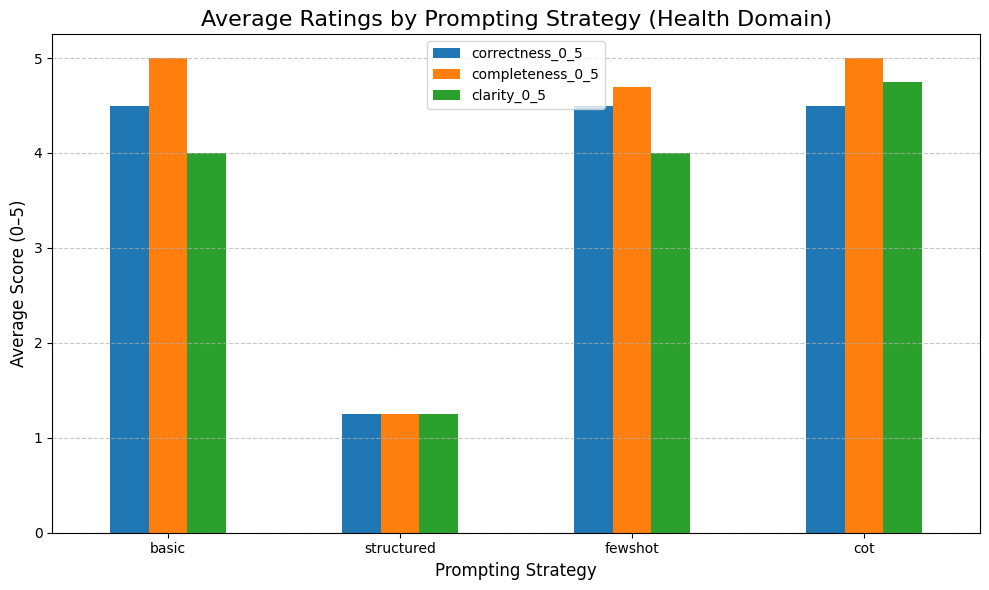

In [12]:
# 8) Visualization

print("\n--- Running Step 8: Visualizing Results ---")
summary.plot(kind="bar", figsize=(10, 6), rot=0)
plt.title("Average Ratings by Prompting Strategy (Health Domain)", fontsize=16)
plt.ylabel("Average Score (0–5)", fontsize=12)
plt.xlabel("Prompting Strategy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "strategy_comparison_plot.png")
plt.savefig(plot_path)
print(f"✅ Plot saved to {plot_path}")
plt.show()
